In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [ ]:
path = kagglehub.dataset_download("altruistdelhite04/loan-prediction-problem-dataset")
file = os.path.join(path, "train_u6lujuX_CVtuZ9i.csv")

df = pd.read_csv(file)

df.head()

Using Colab cache for faster access to the 'loan-prediction-problem-dataset' dataset.


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 529 entries, 1 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             529 non-null    int64  
 1   Married            529 non-null    int64  
 2   Dependents         529 non-null    int64  
 3   Education          529 non-null    int64  
 4   Self_Employed      529 non-null    int64  
 5   ApplicantIncome    529 non-null    int64  
 6   CoapplicantIncome  529 non-null    float64
 7   LoanAmount         529 non-null    float64
 8   Loan_Amount_Term   529 non-null    float64
 9   Credit_History     529 non-null    float64
 10  Property_Area      529 non-null    int64  
 11  Loan_Status        529 non-null    int64  
dtypes: float64(4), int64(8)
memory usage: 53.7 KB


In [ ]:
df.drop("Loan_ID", axis=1, inplace=True)

In [ ]:
df["Loan_Status"] = df["Loan_Status"].map({"Y": 1, "N": 0})

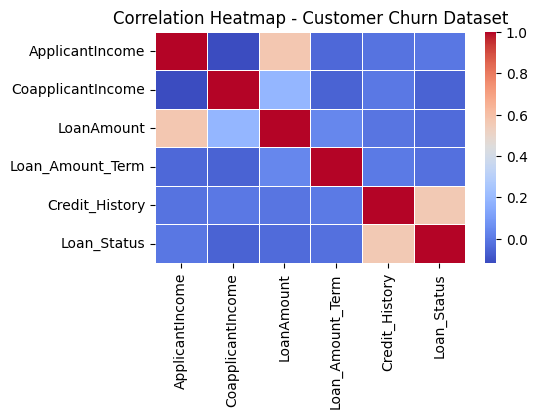

In [ ]:
corr = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(5,3))
sns.heatmap(corr, cmap="coolwarm", annot=False, linewidths=0.5)

plt.title("Correlation Heatmap - Customer Churn Dataset")
plt.show()

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    group1 = df[df["Loan_Status"] == 0][col]
    group2 = df[df["Loan_Status"] == 1][col]
    f_stat, p_val = stats.f_oneway(group1, group2)
    print(col, "p-value:", p_val)

ApplicantIncome p-value: 0.907287812130378
CoapplicantIncome p-value: 0.1429482868428829
LoanAmount p-value: nan
Loan_Amount_Term p-value: nan
Credit_History p-value: nan
Loan_Status p-value: 0.0


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: ConstantInputWarning: Each of the input arrays is constant; the F statistic is not defined or infinite
  res = hypotest_fun_out(*samples, **kwds)


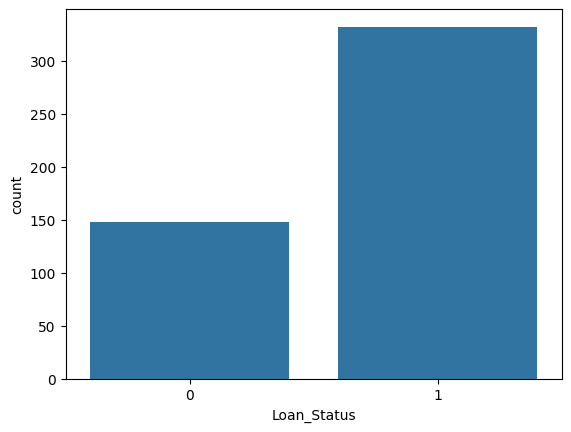

In [ ]:
sns.countplot(x="Loan_Status", data=df)
plt.show()

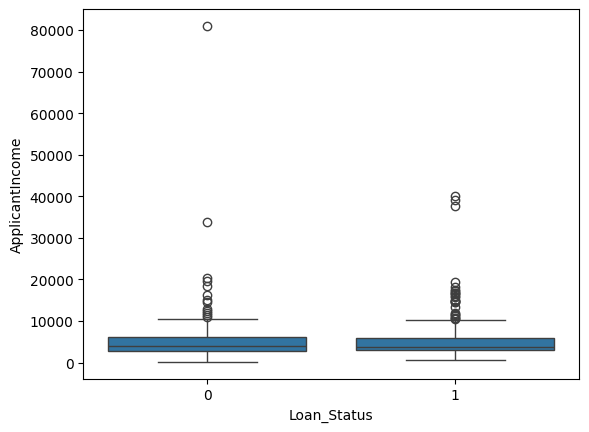

In [ ]:
sns.boxplot(x="Loan_Status", y="ApplicantIncome", data=df)
plt.show()

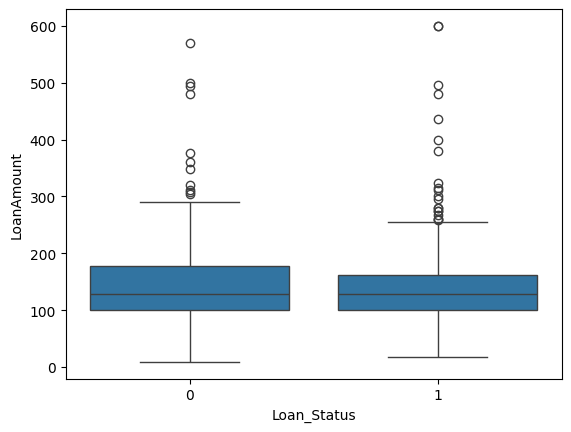

In [ ]:
sns.boxplot(x="Loan_Status", y="LoanAmount", data=df)
plt.show()

In [ ]:
# -----------------------
# ENCODING
# -----------------------
cat_cols = df.select_dtypes(include="object").columns
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

# -----------------------
# TRAIN TEST SPLIT
# -----------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling (important for KNN)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
knn = KNeighborsClassifier()

params = {
    "n_neighbors": [3, 5, 7, 9],
    "weights": ["uniform", "distance"]
}

grid = GridSearchCV(knn, params, cv=5)
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [3, 5, 7, 9],
                         'weights': ['uniform', 'distance']})

In [ ]:
model = grid.best_estimator_

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [ ]:
# EVALUATION
# -----------------------
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

[[13 20]
 [ 3 70]]
              precision    recall  f1-score   support

           0       0.81      0.39      0.53        33
           1       0.78      0.96      0.86        73

    accuracy                           0.78       106
   macro avg       0.80      0.68      0.69       106
weighted avg       0.79      0.78      0.76       106

ROC-AUC: 0.6899128268991283
